In [59]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [60]:

# Read the CSV file into a pandas DataFrame
df = pd.read_csv('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_100.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_100.csv'

In [ ]:

df = pd.read_csv('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_100.csv')

stopwords = ["Unnamed: 0", "common_name"]
levels = [key for key in df.keys().to_list() if key not in stopwords]
levels

edge_list = []
level_list = []

for i in range(len(levels)-1): 
    for j, (first_type, second_type) in df[[levels[i], levels[i+1]]].iterrows(): #  enumerate(df[[levels[i], levels[i+1]]]):
        edge_list.append((first_type, second_type))
        level_list.append(i)

print(edge_list)

[('Rat4', 'Rat'), ('Mouse', 'Mouse'), ('Meerkat4', 'Meerkat'), ('CapraNubiana3', 'Capra Nubiana'), ('Oryx1', 'Oryx'), ('CapraNubiana2', 'Capra Nubiana'), ('Meerkat5', 'Meerkat'), ('Rat5', 'Rat'), ('Colobus2', 'Colobus'), ('ThomsonGazelle', 'Thomson Gazelle'), ('CommonFox', 'Common Fox'), ('PteropusLylei', 'Pteropus Lylei'), ('Oryx2', 'Oryx'), ('Oryx3', 'Oryx'), ('CapraNubiana1', 'Capra Nubiana'), ('HoneyBadger', 'Honey Badger'), ('Rat6', 'Rat'), ('Marmoset', 'Marmoset'), ('ChaerephonPlicata', 'Chaerephon Plicata'), ('Hyrax2', 'Hyrax'), ('DikDik', 'Dik Dik'), ('Lama2', 'Lama'), ('GreenMonkey1', 'Green Monkey'), ('Rat2', 'Rat'), ('Meerkat2', 'Meerkat'), ('Pecari2', 'Pecari'), ('TamarinCottonTop2', 'Tamarin Cotton Top'), ('CapraNubiana4', 'Capra Nubiana'), ('Meerkat3', 'Meerkat'), ('Rat3', 'Rat'), ('Hyrax1', 'Hyrax'), ('GreenMonkey2', 'Green Monkey'), ('Lama1', 'Lama'), ('Rat1', 'Rat'), ('Meerkat1', 'Meerkat'), ('Pecari1', 'Pecari'), ('Rhinolophus', 'Rhinolophus'), ('Merion', 'Merion'), (

In [ ]:
G = nx.from_edgelist(edge_list)
G

ValueError: Received invalid argument(s): nodesize

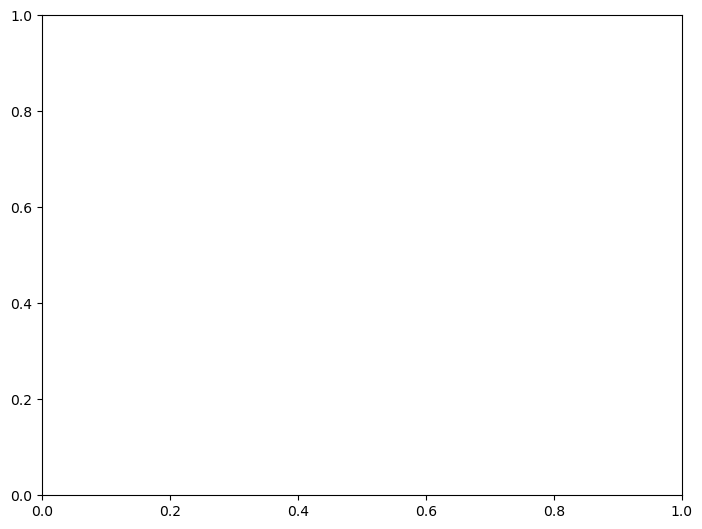

In [ ]:
nx.draw(G, pos=nx.spring_layout(G)) # , nodesize=3) # pos=nx.kamada_kawai_layout(G)) # , **kwargs)


# Use springs
pos = {}

for level, nodes in levels.items():
    y = -level * 2
    for i, node in enumerate(nodes):
        x = (i - len(nodes)/2) * 2
        pos[node] = (x, y)

# Create the plot
plt.figure(figsize=(10, 8)) # 20, 16))

# Define colors for each level
level_colors = {
    -1: '#8b4513',  # Root - brown
    0: '#e74c3c',   # phylogenetic_group - red
    1: '#e67e22',   # super_order - orange
    2: '#f39c12',   # order - yellow
    3: '#2ecc71',   # family - green
    4: '#3498db',   # genus - blue
    5: '#9b59b6'    # animal - purple
}

# Get node colors based on level
node_colors = [level_colors[G.nodes[node]['level']] for node in G.nodes()]

# Get node sizes based on level (smaller for species)
scalar = 100 # 1000 
node_sizes = [3*scalar if G.nodes[node]['level'] == -1 
              else 15*scalar if G.nodes[node]['level'] < 3
              else 8*scalar if G.nodes[node]['level'] < 5
              else 4*scalar for node in G.nodes()]

# Draw the network
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray', 
                       arrows=True, arrowsize=10, width=0.5)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                       node_size=node_sizes, alpha=0.9)

# Draw labels (only for higher levels to avoid clutter)
labels = {}
for node in G.nodes():
    if G.nodes[node]['level'] <= 3:  # Only label up to family level
        labels[node] = G.nodes[node].get('label', node)

nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')

plt.title('Mammal Phylogenetic Tree\n(Taxonomic Hierarchy)', 
          fontsize=20, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

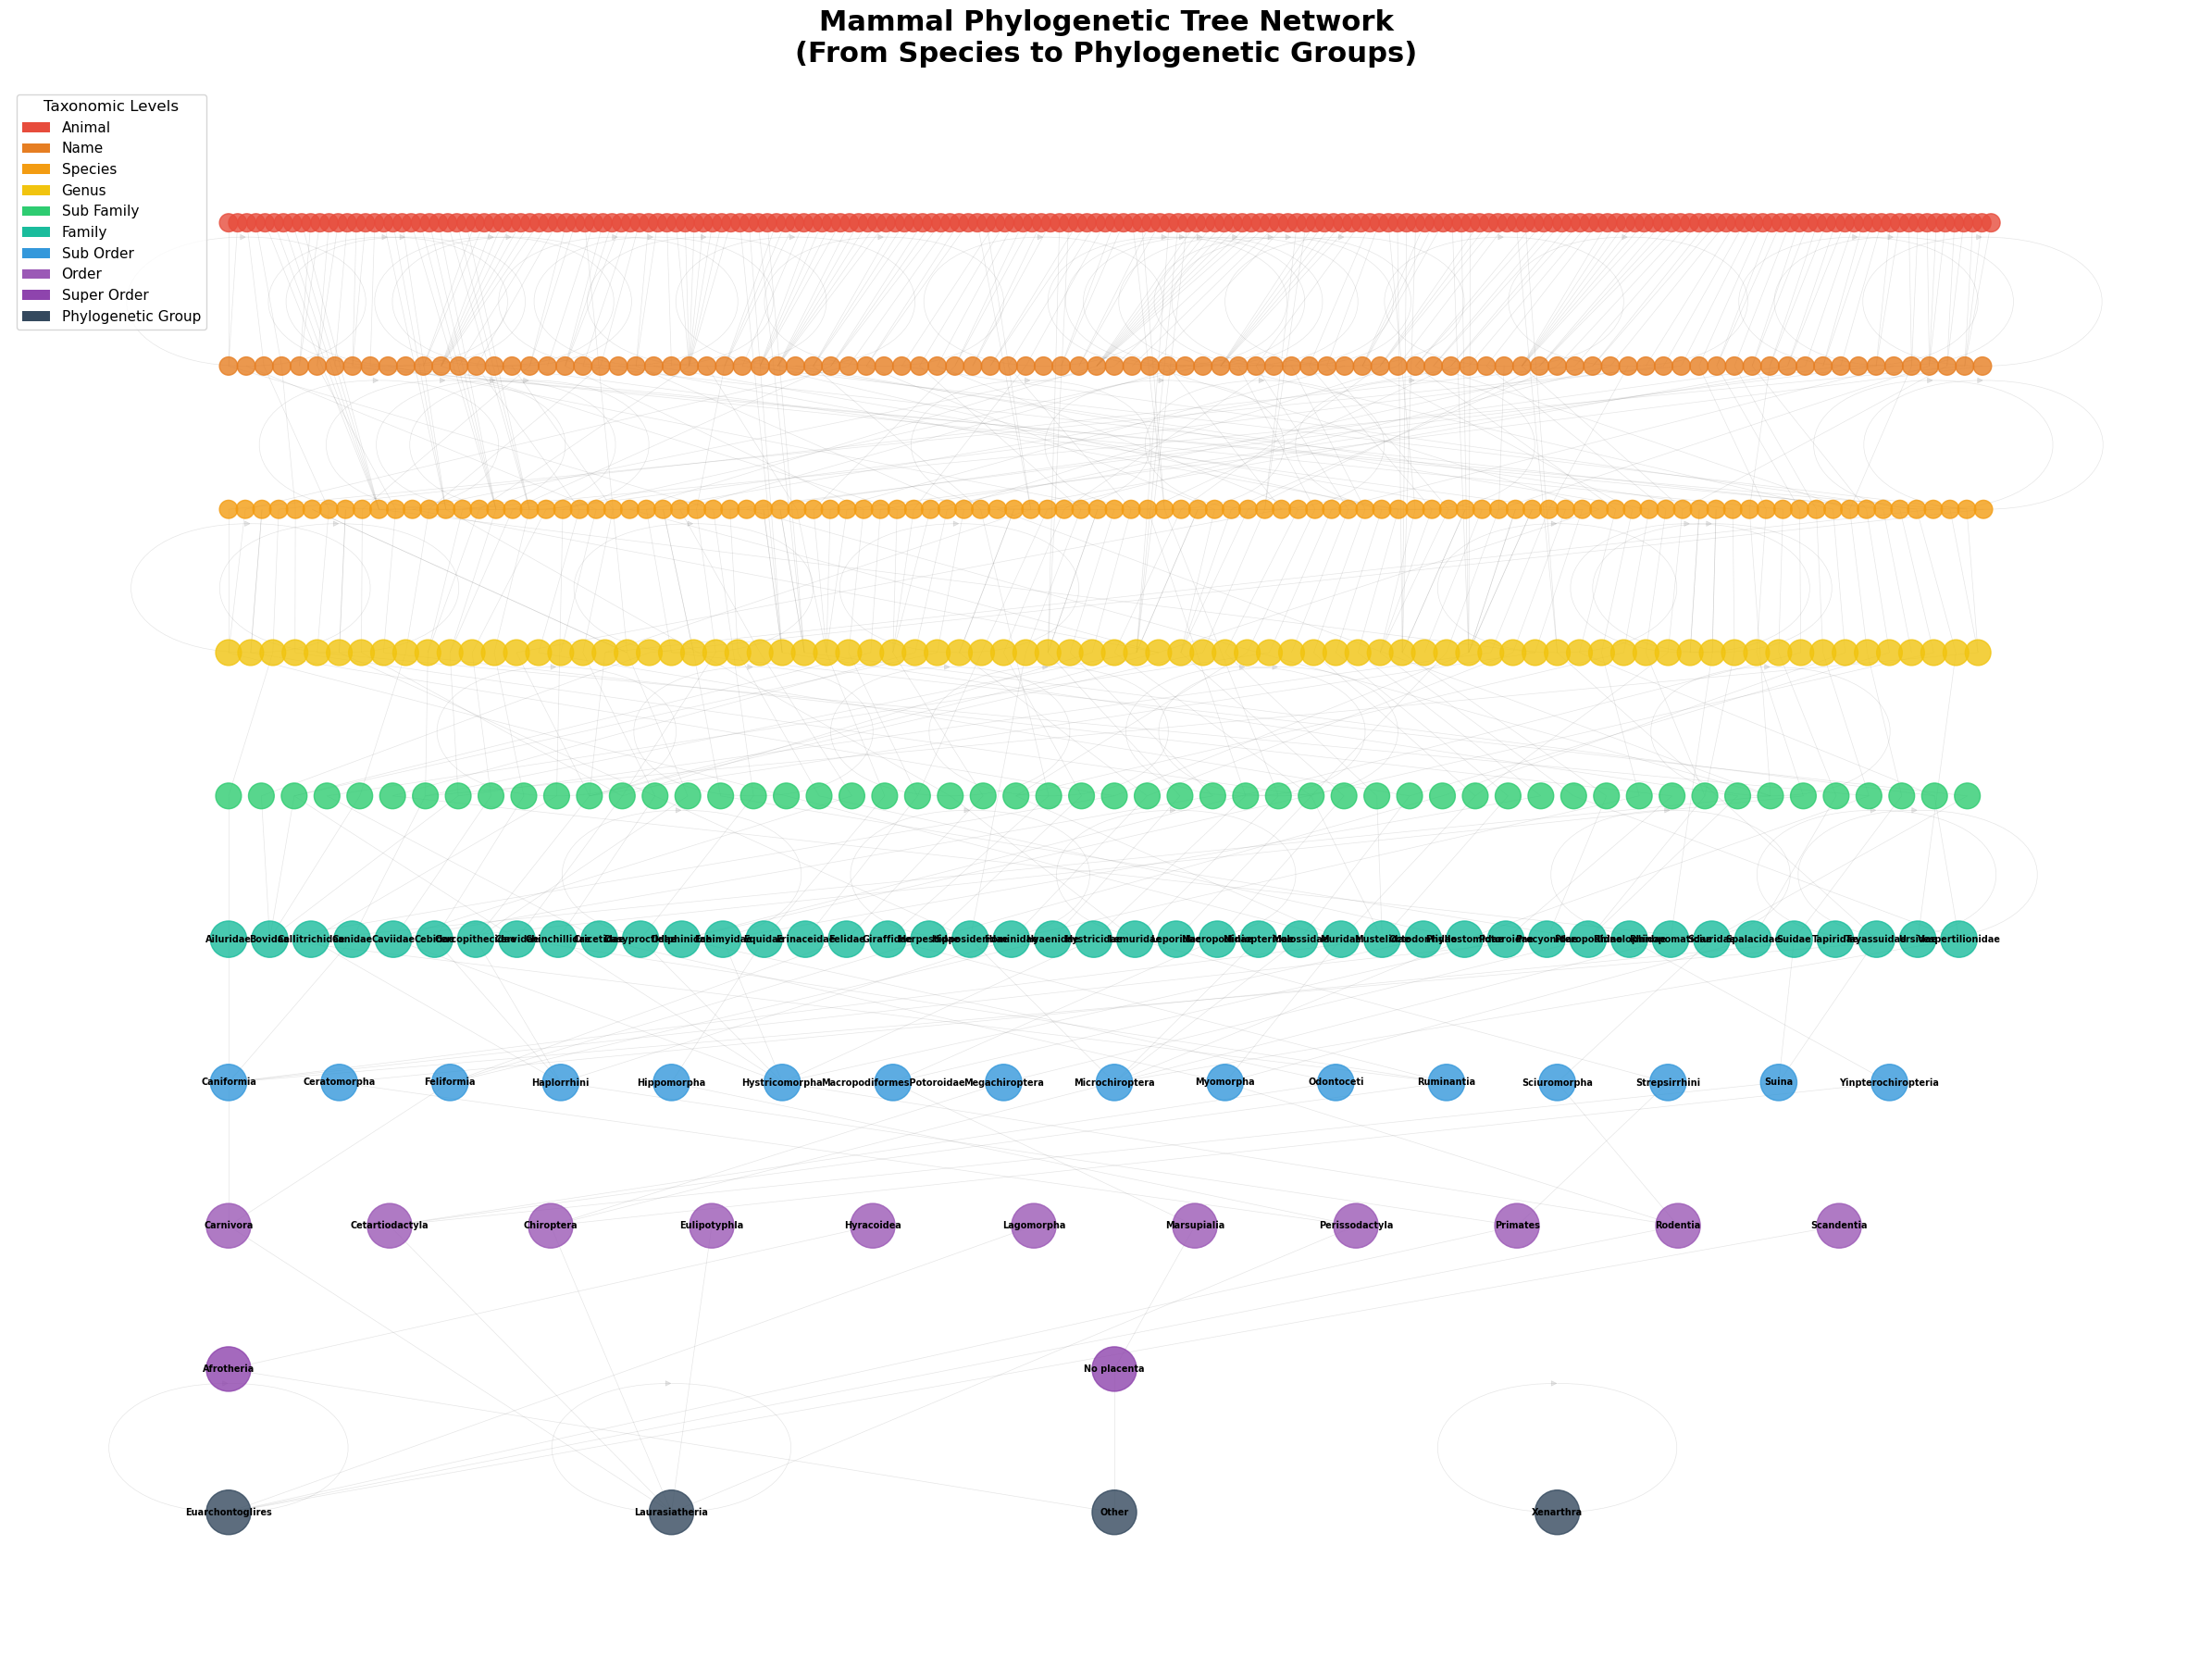


Network Statistics:
Total nodes: 610
Total edges: 655

Nodes per taxonomic level:
  animal              :  194 nodes
  name                :  100 nodes
  species             :  106 nodes
  genus               :   80 nodes
  sub_family          :   54 nodes
  family              :   43 nodes
  sub_order           :   16 nodes
  order               :   11 nodes
  super_order         :    2 nodes
  phylogenetic_group  :    4 nodes

Root nodes (top of hierarchy): 202

Leaf nodes (species/animals): 18


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your data
df = pd.read_csv('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_100.csv')

# Define hierarchy levels
stopwords = ["Unnamed: 0", "common_name"]
levels = [key for key in df.keys().to_list() if key not in stopwords]

# Build edge list
edge_list = []
level_dict = {}  # Track which level each node belongs to

for i in range(len(levels)-1): 
    for j, (first_type, second_type) in df[[levels[i], levels[i+1]]].iterrows():
        if pd.notna(first_type) and pd.notna(second_type) and first_type != '' and second_type != '':
            edge_list.append((first_type, second_type))
            level_dict[first_type] = i
            level_dict[second_type] = i + 1

# Create directed graph
G = nx.DiGraph()
G.add_edges_from(edge_list)

# Assign levels to nodes
nx.set_node_attributes(G, level_dict, 'level')

# Create hierarchical layout manually
pos = {}
level_counts = defaultdict(list)

# Group nodes by level
for node in G.nodes():
    if node in level_dict:
        level_counts[level_dict[node]].append(node)

# Position nodes
for level, nodes in level_counts.items():
    y = -level * 3  # Vertical spacing
    n = len(nodes)
    for i, node in enumerate(sorted(nodes)):
        x = (i - n/2) * (15.0 / max(n, 1))  # Horizontal spacing
        pos[node] = (x, y)

# Create figure
fig, ax = plt.subplots(figsize=(24, 18))

# Define colors for each level
level_colors = {
    0: '#e74c3c',   # animal - red
    1: '#e67e22',   # name - orange
    2: '#f39c12',   # species - yellow
    3: '#f1c40f',   # genus - light yellow
    4: '#2ecc71',   # sub_family - green
    5: '#1abc9c',   # family - teal
    6: '#3498db',   # sub_order - blue
    7: '#9b59b6',   # order - purple
    8: '#8e44ad',   # super_order - dark purple
    9: '#34495e',   # phylogenetic_group - dark gray
}

# Get node colors and sizes based on level
node_colors = []
node_sizes = []
for node in G.nodes():
    level = level_dict.get(node, 0)
    node_colors.append(level_colors.get(level, '#95a5a6'))
    
    # Smaller nodes for species/animals, larger for higher taxonomy
    if level <= 2:
        node_sizes.append(200)
    elif level <= 4:
        node_sizes.append(400)
    elif level <= 6:
        node_sizes.append(800)
    else:
        node_sizes.append(1200)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray', 
                       arrows=False, width=0.5, ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                       node_size=node_sizes, alpha=0.8, ax=ax)

# Draw labels only for higher taxonomy levels (to avoid clutter)
labels = {}
for node in G.nodes():
    level = level_dict.get(node, 0)
    if level >= 5:  # Only show labels for family level and above
        labels[node] = node

nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold', ax=ax)

# Title
ax.set_title('Mammal Phylogenetic Tree Network\n(From Species to Phylogenetic Groups)', 
             fontsize=22, fontweight='bold', pad=20)
ax.axis('off')

# Create legend
from matplotlib.patches import Patch
legend_elements = []
for i, level_name in enumerate(levels):
    if i in level_colors:
        legend_elements.append(
            Patch(facecolor=level_colors[i], label=level_name.replace('_', ' ').title())
        )

ax.legend(handles=legend_elements, loc='upper left', fontsize=11, 
          title='Taxonomic Levels', title_fontsize=12)

plt.tight_layout()
plt.savefig('mammal_phylogenetic_network.png', dpi=300, bbox_inches='tight', 
            facecolor='white')
plt.show()

# Print statistics
print(f"\n{'='*60}")
print(f"Network Statistics:")
print(f"{'='*60}")
print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")
print(f"\nNodes per taxonomic level:")
for level, nodes in sorted(level_counts.items()):
    level_name = levels[level] if level < len(levels) else f"Level {level}"
    print(f"  {level_name:20s}: {len(nodes):4d} nodes")

# Find and display root nodes (nodes with no incoming edges)
root_nodes = [n for n in G.nodes() if G.in_degree(n) == 0]
print(f"\nRoot nodes (top of hierarchy): {len(root_nodes)}")
if len(root_nodes) <= 10:
    for root in root_nodes:
        print(f"  - {root}")

# Find leaf nodes (nodes with no outgoing edges - typically species/animals)
leaf_nodes = [n for n in G.nodes() if G.out_degree(n) == 0]
print(f"\nLeaf nodes (species/animals): {len(leaf_nodes)}")
print(f"{'='*60}")

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Load your data
df = pd.read_csv('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_100.csv')

# Define hierarchy levels
stopwords = ["Unnamed: 0", "common_name"]
levels = [key for key in df.keys().to_list() if key not in stopwords]

# Build edge list
edge_list = []
level_dict = {}

for i in range(len(levels)-1): 
    for j, (first_type, second_type) in df[[levels[i], levels[i+1]]].iterrows():
        if pd.notna(first_type) and pd.notna(second_type) and first_type != '' and second_type != '':
            edge_list.append((first_type, second_type))
            level_dict[first_type] = i
            level_dict[second_type] = i + 1

# Create directed graph
G = nx.DiGraph()
G.add_edges_from(edge_list)
nx.set_node_attributes(G, level_dict, 'level')

# Use graphviz hierarchical layout (much better than manual positioning)
try:
    pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
except:
    # Fallback to improved manual layout if graphviz not available
    pos = {}
    from collections import defaultdict
    level_nodes = defaultdict(list)
    
    # Group nodes by level
    for node in G.nodes():
        if node in level_dict:
            level_nodes[level_dict[node]].append(node)
    
    # Calculate positions with better spacing
    def get_subtree_positions(node, level, x_pos, x_spacing):
        """Recursively position nodes based on their children"""
        children = list(G.successors(node))
        
        if not children:
            pos[node] = (x_pos, -level * 2)
            return x_pos, x_pos
        
        # Position children first
        child_x_positions = []
        current_x = x_pos
        
        for child in children:
            start_x, end_x = get_subtree_positions(child, level + 1, current_x, x_spacing)
            child_x_positions.append((start_x + end_x) / 2)
            current_x = end_x + x_spacing
        
        # Position parent at center of children
        if child_x_positions:
            parent_x = (child_x_positions[0] + child_x_positions[-1]) / 2
        else:
            parent_x = x_pos
            
        pos[node] = (parent_x, -level * 2)
        return min(child_x_positions + [parent_x]), max(child_x_positions + [parent_x])
    
    # Find root nodes and position tree
    root_nodes = [n for n in G.nodes() if G.in_degree(n) == 0]
    current_x = 0
    for root in sorted(root_nodes):
        _, end_x = get_subtree_positions(root, level_dict.get(root, 0), current_x, 0.5)
        current_x = end_x + 2

# Create figure with better size
fig, ax = plt.subplots(figsize=(28, 20))

# Define colors for each level with better palette
level_colors = {
    0: '#e74c3c',   # animal - red
    1: '#e67e22',   # name - orange  
    2: '#f39c12',   # species - yellow
    3: '#f1c40f',   # genus - light yellow
    4: '#2ecc71',   # sub_family - green
    5: '#1abc9c',   # family - teal
    6: '#3498db',   # sub_order - blue
    7: '#9b59b6',   # order - purple
    8: '#8e44ad',   # super_order - dark purple
    9: '#34495e',   # phylogenetic_group - dark gray
}

# Get node properties
node_colors = []
node_sizes = []
for node in G.nodes():
    level = level_dict.get(node, 0)
    node_colors.append(level_colors.get(level, '#95a5a6'))
    
    # Graduated node sizes
    if level <= 1:
        node_sizes.append(100)
    elif level <= 3:
        node_sizes.append(200)
    elif level <= 5:
        node_sizes.append(400)
    elif level <= 7:
        node_sizes.append(700)
    else:
        node_sizes.append(1000)

# Draw edges with curved style
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='#7f8c8d', 
                       arrows=True, arrowsize=10, width=1.5, 
                       arrowstyle='->', connectionstyle='arc3,rad=0.1', ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                       node_size=node_sizes, alpha=0.85, 
                       linewidths=1.5, edgecolors='white', ax=ax)

# Smart labeling: show labels based on importance and space
labels = {}
for node in G.nodes():
    level = level_dict.get(node, 0)
    # Show labels for middle to high taxonomy (family and above) and avoid clutter
    if level >= 5:
        labels[node] = node
    elif level == 4 and len(list(G.successors(node))) > 3:  # Important subfamily nodes
        labels[node] = node

nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold', 
                        font_family='sans-serif', ax=ax)

# Title
ax.set_title('Mammal Phylogenetic Hierarchy Network\nFrom Individual Animals to Major Phylogenetic Groups', 
             fontsize=26, fontweight='bold', pad=30, family='sans-serif')
ax.axis('off')

# Create better legend
legend_elements = []
for i, level_name in enumerate(levels):
    if i in level_colors:
        legend_elements.append(
            Patch(facecolor=level_colors[i], edgecolor='white', linewidth=1.5,
                  label=level_name.replace('_', ' ').title())
        )

legend = ax.legend(handles=legend_elements, loc='upper left', fontsize=12, 
                   title='Taxonomic Levels', title_fontsize=14, 
                   frameon=True, fancybox=True, shadow=True)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.savefig('mammal_phylogenetic_network_improved.png', dpi=300, 
            bbox_inches='tight', facecolor='white')
plt.show()

# Print enhanced statistics
print(f"\n{'='*70}")
print(f"MAMMAL PHYLOGENETIC NETWORK STATISTICS")
print(f"{'='*70}")
print(f"\nNetwork Overview:")
print(f"  Total nodes: {G.number_of_nodes():,}")
print(f"  Total edges: {G.number_of_edges():,}")
print(f"  Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

print(f"\nNodes per Taxonomic Level:")
from collections import defaultdict
level_counts = defaultdict(list)
for node in G.nodes():
    if node in level_dict:
        level_counts[level_dict[node]].append(node)

for level, nodes in sorted(level_counts.items()):
    level_name = levels[level] if level < len(levels) else f"Level {level}"
    print(f"  {level_name:20s}: {len(nodes):4d} nodes")

# Analyze connectivity
root_nodes = [n for n in G.nodes() if G.in_degree(n) == 0]
leaf_nodes = [n for n in G.nodes() if G.out_degree(n) == 0]

print(f"\nHierarchy Structure:")
print(f"  Root nodes (top of tree): {len(root_nodes)}")
print(f"  Leaf nodes (bottom/species): {len(leaf_nodes)}")
print(f"  Average children per parent: {G.number_of_edges() / (G.number_of_nodes() - len(leaf_nodes)):.2f}")

# Show sample of top-level taxonomy
print(f"\nTop-Level Phylogenetic Groups:")
top_level = max(level_counts.keys())
for node in sorted(level_counts[top_level])[:10]:
    descendants = len(nx.descendants(G, node))
    print(f"  • {node}: {descendants} descendants")

print(f"{'='*70}\n")

RecursionError: maximum recursion depth exceeded

In [61]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your data
df = pd.read_csv('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_100.csv')

# Define hierarchy levels
stopwords = ["Unnamed: 0", "common_name"]
levels = [key for key in df.keys().to_list() if key not in stopwords]

# Build edge list
edge_list = []
level_dict = {}  # Track which level each node belongs to

for i in range(len(levels)-1): 
    for j, (first_type, second_type) in df[[levels[i], levels[i+1]]].iterrows():
        if pd.notna(first_type) and pd.notna(second_type) and first_type != '' and second_type != '':
            if first_type != second_type: 
                edge_list.append((first_type, second_type))
                level_dict[first_type] = i
                level_dict[second_type] = i + 1

# Create directed graph
G = nx.DiGraph()
G.add_edges_from(edge_list)

# Assign levels to nodes
nx.set_node_attributes(G, level_dict, 'level')

# Create hierarchical layout manually
pos = {}
level_counts = defaultdict(list)

# Group nodes by level
for node in G.nodes():
    if node in level_dict:
        level_counts[level_dict[node]].append(node)

# Position nodes
# for level, nodes in level_counts.items():
#     y = -level * 3  # Vertical spacing
#     n = len(nodes)
#     for i, node in enumerate(sorted(nodes)):
#         x = (i - n/2) * (15.0 / max(n, 1))  # Horizontal spacing
#         pos[node] = (x, y)

# Create figure
fig, ax = plt.subplots(figsize=(24, 18))

# Define colors for each level
level_colors = {
    0: '#e74c3c',   # animal - red
    1: '#e67e22',   # name - orange
    2: '#f39c12',   # species - yellow
    3: '#f1c40f',   # genus - light yellow
    4: '#2ecc71',   # sub_family - green
    5: '#1abc9c',   # family - teal
    6: '#3498db',   # sub_order - blue
    7: '#9b59b6',   # order - purple
    8: '#8e44ad',   # super_order - dark purple
    9: '#34495e',   # phylogenetic_group - dark gray
}

# Get node colors and sizes based on level
node_colors = []
node_sizes = []
for node in G.nodes():
    level = level_dict.get(node, 0)
    node_colors.append(level_colors.get(level, '#95a5a6'))
    
    # Smaller nodes for species/animals, larger for higher taxonomy
    if level <= 2:
        node_sizes.append(200)
    elif level <= 4:
        node_sizes.append(400)
    elif level <= 6:
        node_sizes.append(800)
    else:
        node_sizes.append(1200)

pos=nx.spring_layout(G, scale=0.5, iterations=100)

# Draw edges
nx.draw_networkx_edges(G, 
                       pos=pos, 
                       alpha=0.2, edge_color='gray', 
                       arrows=False, 
                       width=2, # 0.5, 
                       ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G, 
                       pos=pos, 
                       node_color=node_colors, 
                       node_size=node_sizes, 
                       alpha=0.8, 
                       ax=ax)

# Draw labels only for higher taxonomy levels (to avoid clutter)
labels = {}
for node in G.nodes():
    level = level_dict.get(node, 0)
    # if level >= 5:  # Only show labels for family level and above
    #     labels[node] = node
    labels[node] = node

nx.draw_networkx_labels(G, 
                        pos=pos, 
                        labels=labels, 
                        font_size=9, font_weight='bold', ax=ax)

# Title
ax.set_title('Mammal Phylogenetic Tree Network\n(From Species to Phylogenetic Groups)', 
             fontsize=22, fontweight='bold', pad=20)
ax.axis('off')

# Create legend
from matplotlib.patches import Patch
legend_elements = []
for i, level_name in enumerate(levels):
    if i in level_colors:
        legend_elements.append(
            Patch(facecolor=level_colors[i], label=level_name.replace('_', ' ').title())
        )

ax.legend(handles=legend_elements, loc='upper left', fontsize=11, 
          title='Taxonomic Levels', title_fontsize=12)

plt.tight_layout()
plt.savefig('mammal_phylogenetic_network.png', dpi=300, bbox_inches='tight', 
            facecolor='white')
plt.show()

# Print statistics
print(f"\n{'='*60}")
print(f"Network Statistics:")
print(f"{'='*60}")
print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")
print(f"\nNodes per taxonomic level:")
for level, nodes in sorted(level_counts.items()):
    level_name = levels[level] if level < len(levels) else f"Level {level}"
    print(f"  {level_name:20s}: {len(nodes):4d} nodes")

# Find and display root nodes (nodes with no incoming edges)
root_nodes = [n for n in G.nodes() if G.in_degree(n) == 0]
print(f"\nRoot nodes (top of hierarchy): {len(root_nodes)}")
if len(root_nodes) <= 10:
    for root in root_nodes:
        print(f"  - {root}")

# Find leaf nodes (nodes with no outgoing edges - typically species/animals)
leaf_nodes = [n for n in G.nodes() if G.out_degree(n) == 0]
print(f"\nLeaf nodes (species/animals): {len(leaf_nodes)}")
print(f"{'='*60}")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_100.csv'

## Densities in GNM


In [4]:
c.sum()


np.float32(924.0)

In [ ]:
924 / ()

924

In [20]:
import numpy as np 
c = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/49_suarez_MaMI_100_animal_11/generated_networks/net_eta-0.3087339401245117_gamma0.43720197677612305_ruleMatchingIndex.npy") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/49_suarez_MaMI_100_animal_3/generated_networks/net_eta-0.8093185424804688_gamma-0.9314519166946411_ruleMatchingIndex.npy")
print(c.shape)

# Density as def by GNM: 

# kden = k / ((n * n - n) / 2) (where k is the number of edges - or the number of non-zero entries??) 

CIJ = c[0,:,:]
n = len(CIJ)
k = np.size(np.where(np.triu(CIJ).flatten()))
kden = k / ((n * n - n) / 2)

kden

(1, 100, 100)


0.1

0.20280948200175591

In [ ]:
kden * ((n * n - n) / 2) = n_edges

In [10]:
import numpy as np 
import matplotlib.pyplot as plt
import torch 


bin_con = torch.Tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

TypeError: must be real number, not ellipsis

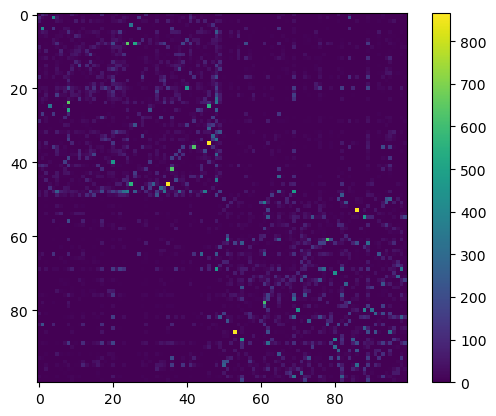

In [57]:

import matplotlib.pyplot as plt
# data = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_100.npy")
data_dist = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/00_preprocessed/connectomes_downsampled_to_50/Capybara.npy") 
                    # "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/00_preprocessed/dis_matrices_downsampled_to_50/Koala.npy") 
# /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/00_preprocessed/dis_matrices_downsampled_to_50/BrownLemur2.npy") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_50.npy") 
# /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_orig.npy") 
# /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/distance_matrix_50.npy") 
# data_dist = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/distance_matrix_orig.npy")
# /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/distance_matrix_100.npy")

# data = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_orig.npy")
plt.imshow(data_dist) # [0]) # data[0]) # distance_matrix - data_dist[42])
plt.colorbar()


In [16]:
data.shape 

(225, 100, 100)

In [17]:
data.sum(axis=2).shape

(225, 100)

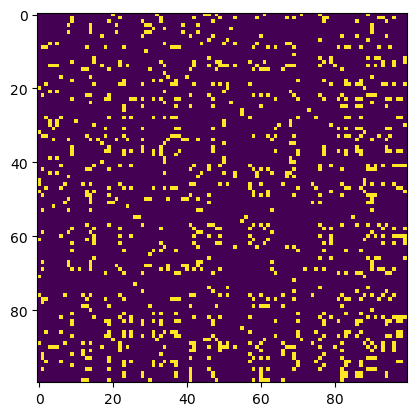

In [19]:
plt.imshow(data[42]) # data[0]-data[3])

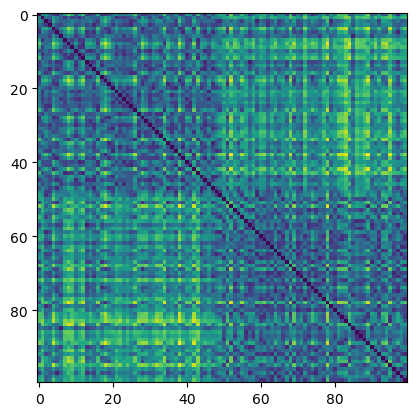

In [12]:
plt.imshow()

In [22]:
from src.visualization.find_and_plot_closest_connectome import find_closest_connectome, plot_connectome, compare_orderings

TypeError: Invalid shape (225, 200, 200) for image data

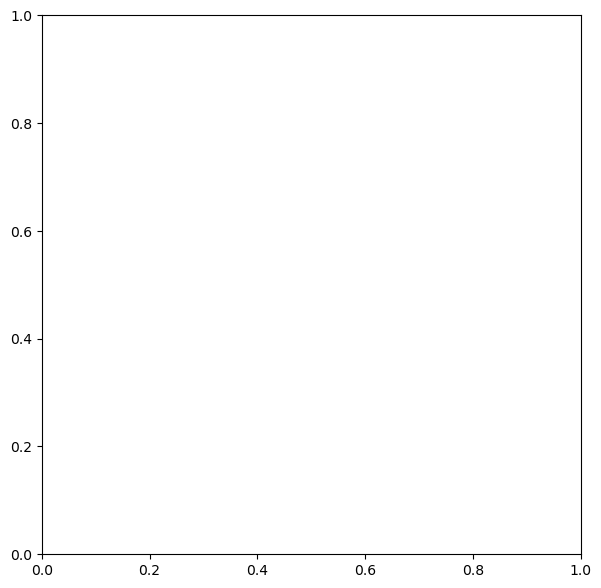

In [39]:
# Connectomes before resampling: 
con = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_orig.npy") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/conn_50/Otter1.npy")

# # Connectome after resampling to 100 and thresholding and binarizing
# conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_50.npy")
# con = conns[0] # -> That's a bad idea: Has multiple nodes that are identical each. 


# Generated connectomes: 
# path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/52_suarez_MaMI_100/generated_networks/net_eta-1.9832448959350586_gamma0.13711559772491455_ruleMatchingIndex.npy"
# conns = np.load(path)
# con = conns[0]

# Connectomes after resampling
# path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_50.npy"
# conns = np.load(path)
# con = conns[0]



# Choose clustering method: 'spectral', 'hierarchical', 'modularity', 'degree', or None
clustering_method = 'spectral'  # Change this to experiment with different orderings

# Plot original (unordered) connectome
save_path = plot_connectome(con, 
                            found_eta=42, 
                            found_gamma=42, 
                            data_dir=".", 
                            save_subdir="connectome_plots",
                            cluster_method=None)

# Plot clustered connectome
# plot_connectome(con, 
#                 found_eta=42, 
#                 found_gamma=42, 
#                 data_dir=".", 
#                 save_subdir="connectome_plots",
#                 cluster_method=clustering_method)

# Optional: Create comparison plot of all ordering methods
# compare_orderings(connectome, found_eta, found_gamma, data_dir)


Plot saved to: connectome_plots/adjacency_matrix_connectome_eta42.000_gamma42.000.png


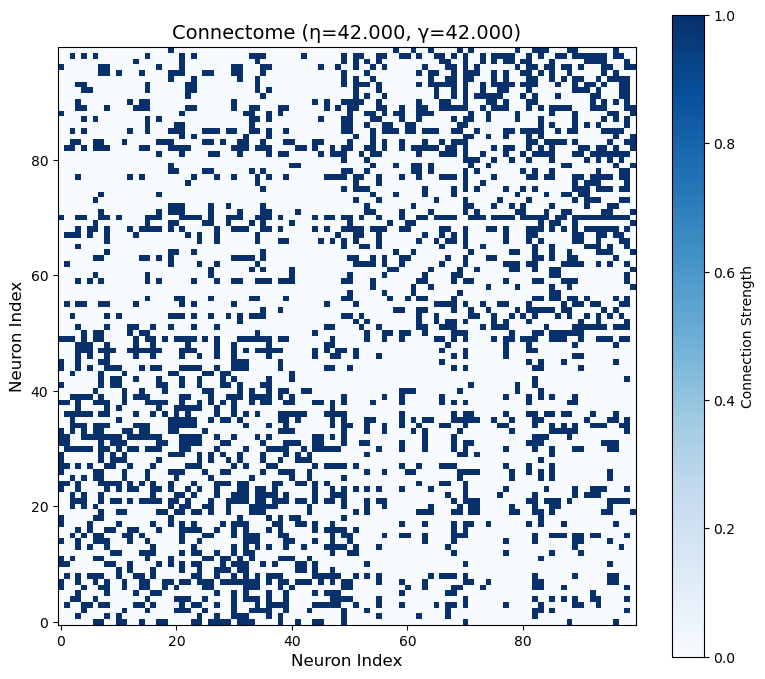

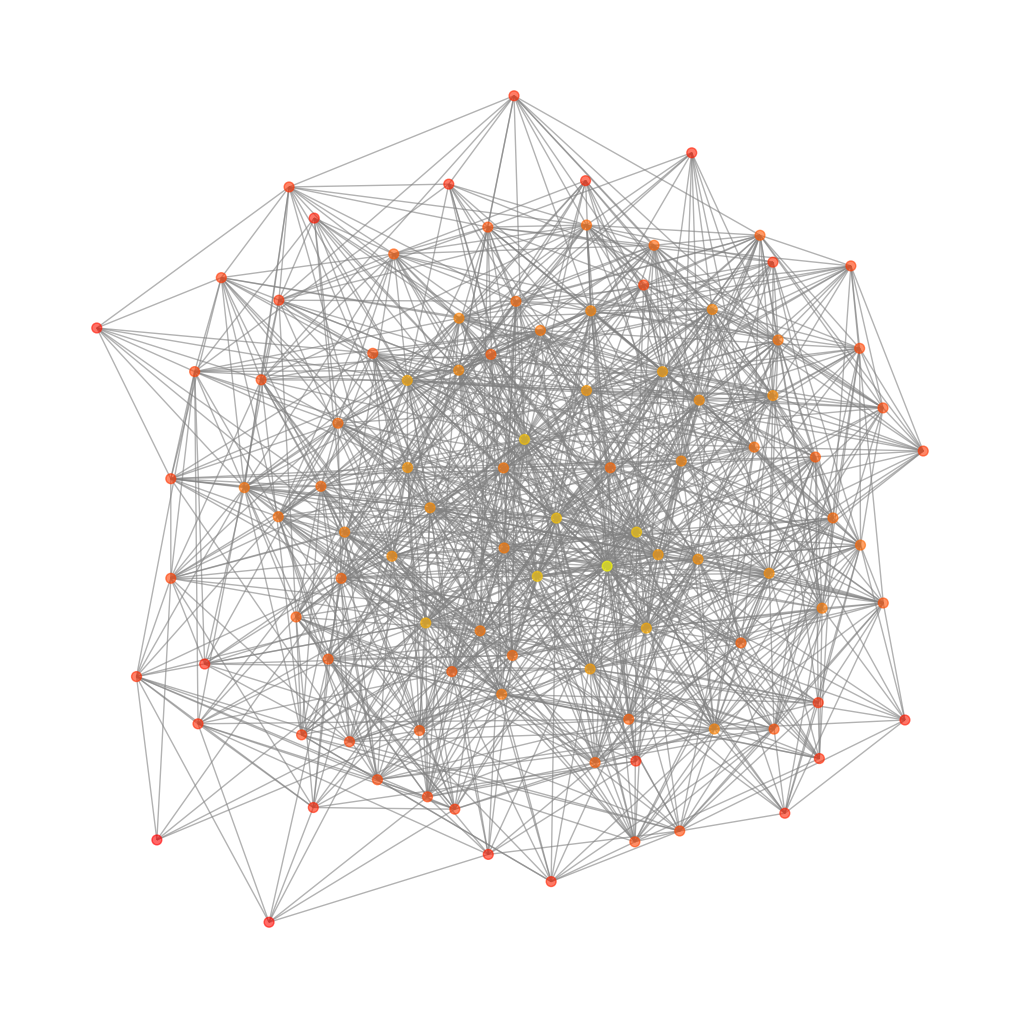

Reordering connectome using method: spectral
Plot saved to: connectome_plots/adjacency_matrix_connectome_eta42.000_gamma42.000_spectral.png


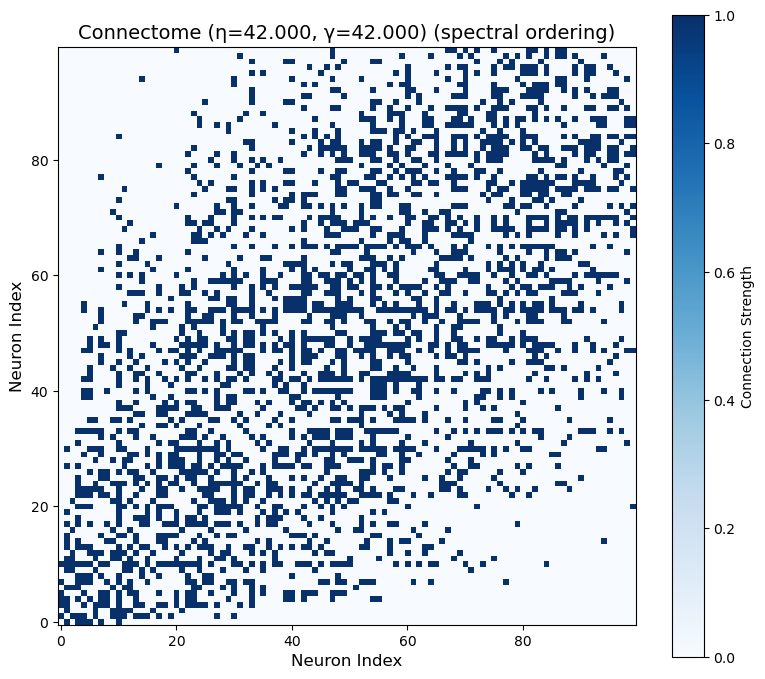

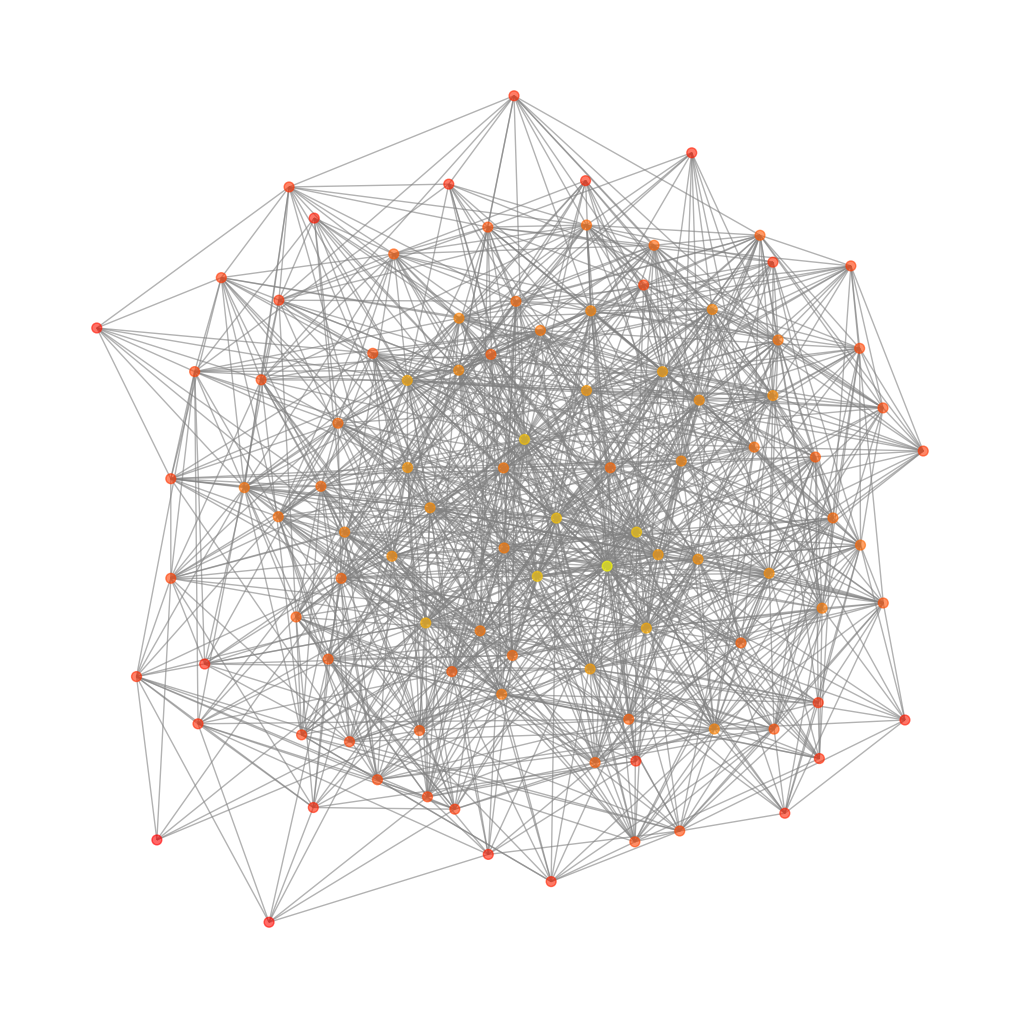

PosixPath('connectome_plots')

In [ ]:
# Connectomes before resampling: 
con = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/conn_50/Otter1.npy").astype(bool)

# # Connectome after resampling to 100 and thresholding and binarizing
# conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_50.npy")
# con = conns[0] # -> That's a bad idea: Has multiple nodes that are identical each. 


# Generated connectomes: 
# path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/52_suarez_MaMI_100/generated_networks/net_eta-1.9832448959350586_gamma0.13711559772491455_ruleMatchingIndex.npy"
# conns = np.load(path)
# con = conns[0]

# Connectomes after resampling
# path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_50.npy"
# conns = np.load(path)
# con = conns[0]



# Choose clustering method: 'spectral', 'hierarchical', 'modularity', 'degree', or None
clustering_method = 'spectral'  # Change this to experiment with different orderings

# Plot original (unordered) connectome
save_path = plot_connectome(con, 
                            found_eta=42, 
                            found_gamma=42, 
                            data_dir=".", 
                            save_subdir="connectome_plots",
                            cluster_method=None)

# Plot clustered connectome
plot_connectome(con, 
                found_eta=42, 
                found_gamma=42, 
                data_dir=".", 
                save_subdir="connectome_plots",
                cluster_method=clustering_method)

# Optional: Create comparison plot of all ordering methods
# compare_orderings(connectome, found_eta, found_gamma, data_dir)


Plot saved to: connectome_plots/adjacency_matrix_connectome_eta42.000_gamma42.000.png


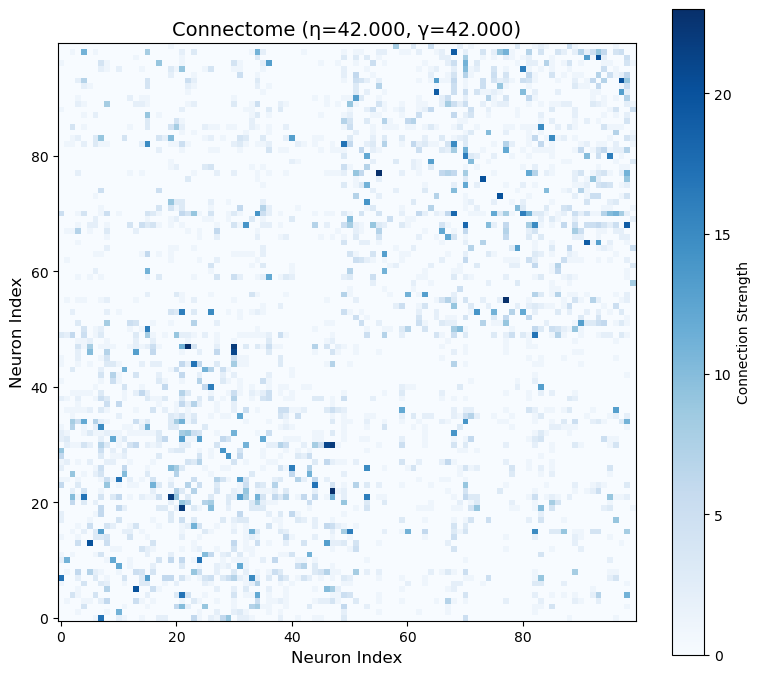

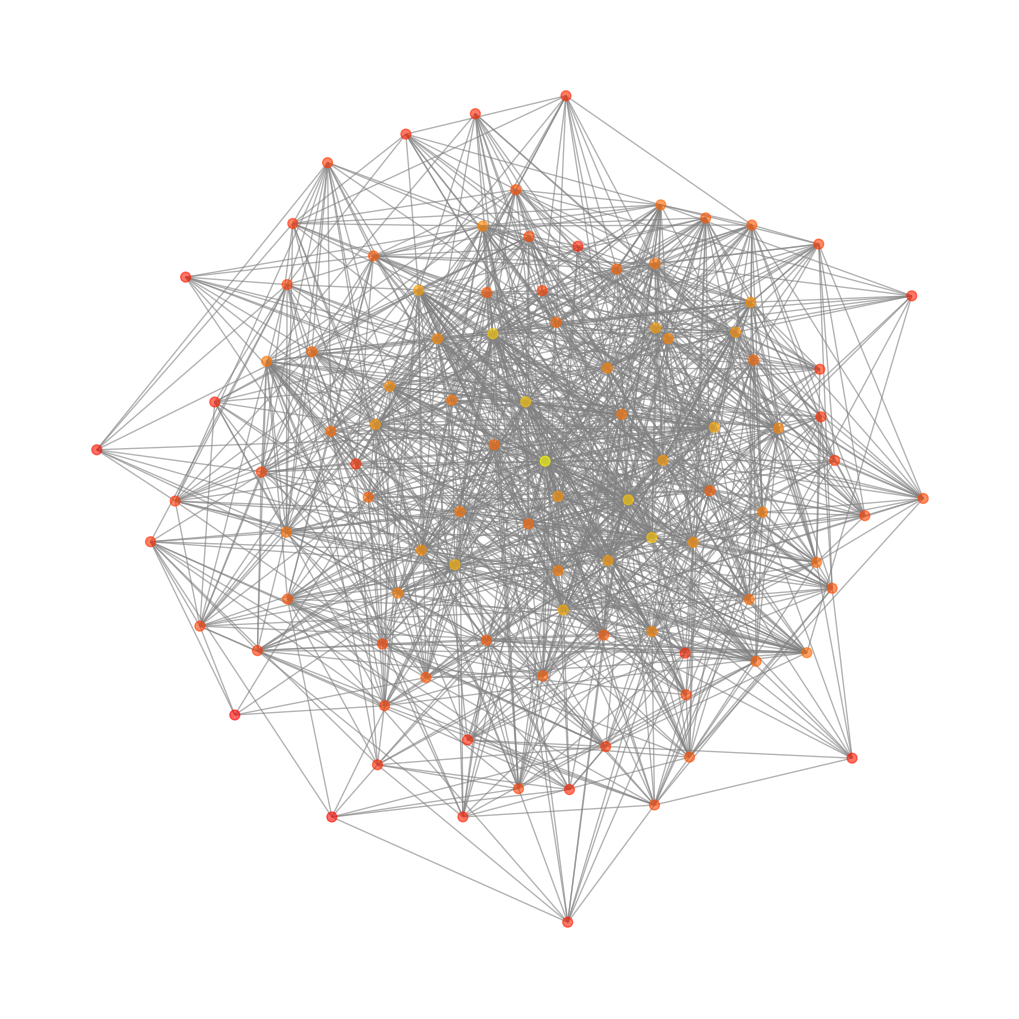

Reordering connectome using method: spectral
Plot saved to: connectome_plots/adjacency_matrix_connectome_eta42.000_gamma42.000_spectral.png


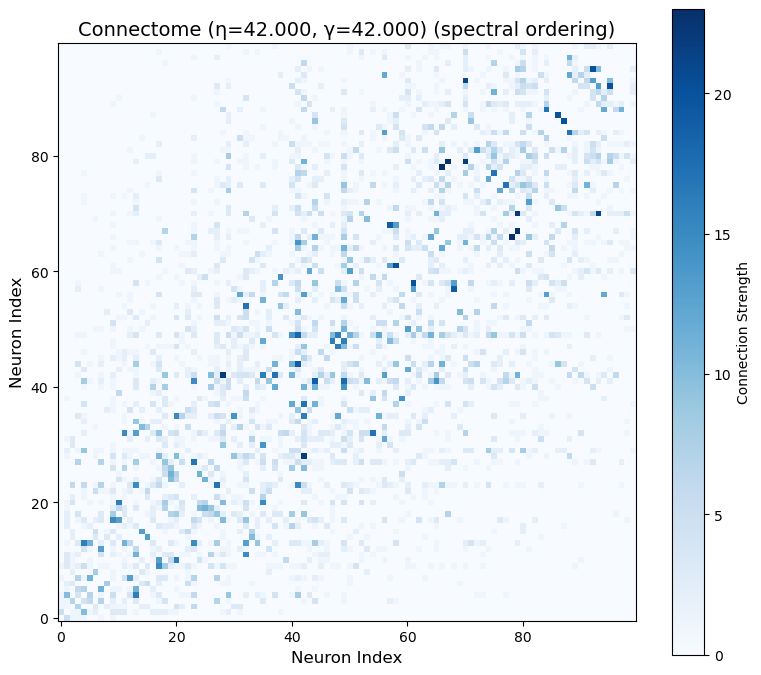

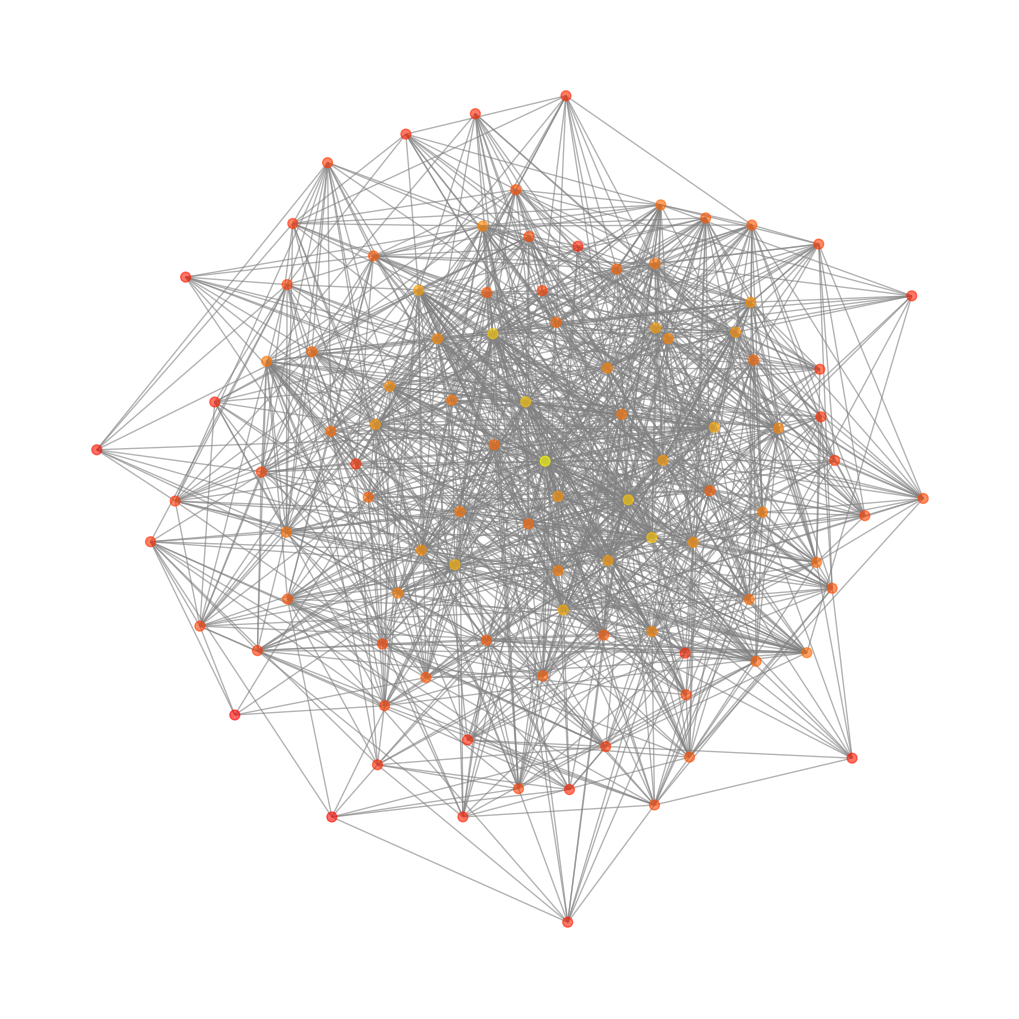

PosixPath('connectome_plots')

In [28]:
# conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_100.npy")
# con = conns[0]

con = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/conn_50/Otter1.npy")


# Choose clustering method: 'spectral', 'hierarchical', 'modularity', 'degree', or None
clustering_method = 'spectral'  # Change this to experiment with different orderings

# Plot original (unordered) connectome
save_path = plot_connectome(con, 
                            found_eta=42, 
                            found_gamma=42, 
                            data_dir=".", 
                            save_subdir="connectome_plots",
                            cluster_method=None)

# Plot clustered connectome
plot_connectome(con, 
                found_eta=42, 
                found_gamma=42, 
                data_dir=".", 
                save_subdir="connectome_plots",
                cluster_method=clustering_method)

# Optional: Create comparison plot of all ordering methods
# compare_orderings(connectome, found_eta, found_gamma, data_dir)


In [ ]:
# """
#     Find optimal pairs and merge them, but only pair nodes within the same half.
#     First half pairs with first half, second half pairs with second half.
    
#     Parameters:
#     - points: numpy array of shape (n, 3) with 3D coordinates
#     - connection_matrix: numpy array of shape (n, n) representing connections
    
#     Returns:
#     - new_points: merged coordinates (average of paired points)
#     - new_matrix: merged connection matrix
#     - pairs: list of node pairs that were merged
#     """
#     n = len(points)
#     if n % 2 != 0:
#         raise ValueError("Number of points must be even")
    
#     mid = n // 2
    
#     # Split into two halves
#     first_half = list(range(mid))
#     second_half = list(range(mid, n))
    
#     if len(first_half) % 2 != 0 or len(second_half) % 2 != 0:
#         raise ValueError("Each half must have an even number of points")
    
#     def find_matching_in_subset(indices):
#         """Find minimum weight matching within a subset of indices"""
#         if len(indices) == 0:
#             return []
        
#         G = nx.Graph()
#         for i in indices:
#             for j in indices:
#                 if i < j:
#                     dist = np.linalg.norm(points[i] - points[j])
#                     G.add_edge(i, j, weight=dist)
        
#         matching = nx.min_weight_matching(G)
#         return list(matching)
    
#     # Find matching separately for each half
#     pairs_first = find_matching_in_subset(first_half)
#     pairs_second = find_matching_in_subset(second_half)
    
#     # Combine all pairs
#     pairs = pairs_first + pairs_second
    
#     # Create mapping from old indices to new indices
#     old_to_new = {}
#     new_idx = 0
#     for i, j in pairs:
#         old_to_new[i] = new_idx
#         old_to_new[j] = new_idx
#         new_idx += 1
    
#     # Merge coordinates (average of paired points)
#     new_points = []
#     for i, j in pairs:
#         merged_point = (points[i] + points[j]) / 2
#         new_points.append(merged_point)
#     new_points = np.array(new_points)
    
#     # Merge connection matrix
#     n_new = len(pairs)
#     new_matrix = np.zeros((n_new, n_new))
    
#     for old_i in range(n):
#         for old_j in range(n):
#             new_i = old_to_new[old_i]
#             new_j = old_to_new[old_j]
            
#             # Sum connections (or use max, depending on your needs)
#             new_matrix[new_i, new_j] += connection_matrix[old_i, old_j]
    
#     return new_points, new_matrix, pairs

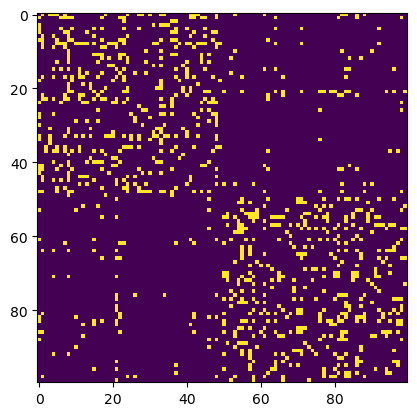

In [69]:
plt.imshow(np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_50.npy")[3])

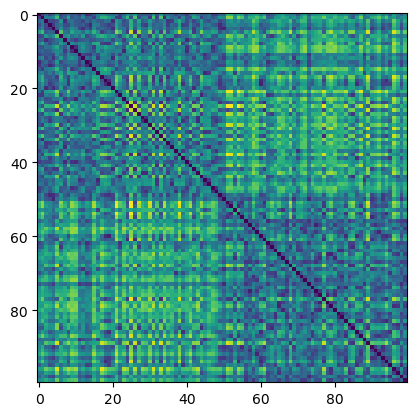

In [72]:
plt.imshow(np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/distance_matrix_50.npy")[5])